## read the json

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json

def read_jsonl(filepath):
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                data.append(json.loads(line))
    return data

def get_group_mapping(file_name='grpo_150.jsonl', entropy_threshold=0.1):
    jsonl_data = read_jsonl(file_name)
    # non_tensor_data = jsonl_data[:len(jsonl_data)//2]
    tensor_data = jsonl_data[len(jsonl_data)//2:]
    # tensor_data[0].keys() #['input_ids', 'log_probs', 'old_log_probs', 'entropy', 'ref_log_probs', 'advantages']
    entropy_mean = 0
    for idx in range(len(tensor_data)):
        log_probs = tensor_data[idx]['log_probs']
        reverse_idx = -1
        for i, val in enumerate(reversed(log_probs), 1):  # 1-based index from right
            if val != 0:
                reverse_idx = i
                break
        mask_idx = len(log_probs) - reverse_idx

        tensor_data[idx]['mask_idx'] = mask_idx

        advantage_val = tensor_data[idx].get('advantages', 0)
        entropy = np.array(tensor_data[idx].get('entropy', 0))[:mask_idx]
        IS = (np.exp(np.array(tensor_data[idx]['log_probs'])) - np.exp(np.array(tensor_data[idx]['old_log_probs'])))[:mask_idx]

        entropy_mean += entropy.mean()

        adv_flag = 1 if advantage_val > 0 else 0   
        ent_flag = 1 if entropy.mean() > entropy_threshold else 0  
        is_flag = 1 if IS.mean() > 0 else 0       
        # group_mapping has 8 values:
        # 0: advantage<=0, entropy<=tau, IS<=0
        # 1: advantage<=0, entropy<=tau, IS>0
        # 2: advantage<=0, entropy>tau, IS<=0
        # 3: advantage<=0, entropy>tau, IS>0
        # 4: advantage>0,  entropy<=tau, IS<=0
        # 5: advantage>0,  entropy<=tau, IS>0
        # 6: advantage>0,  entropy>tau, IS<=0
        # 7: advantage>0,  entropy>tau, IS>0
        tensor_data[idx]['group_mapping'] = (adv_flag << 2) | (ent_flag << 1) | is_flag
    entropy_mean /= len(tensor_data)
    
    return tensor_data, entropy_mean


In [ ]:
from collections import defaultdict
import numpy as np

def get_group_kld(tensor_data):
    group_kld_dict = defaultdict(list)
    for idx in range(len(tensor_data)):
        group_id = tensor_data[idx]['group_mapping']
        mask_idx = tensor_data[idx]['mask_idx']
        kl = (np.array(tensor_data[idx]['ref_log_probs']) - np.array(tensor_data[idx]['log_probs']))[:mask_idx]
        ratio = np.exp(kl)
        kld = (ratio - kl - 1)
        kld = np.clip(kld, a_min=-10, a_max=10).mean()
        if np.isnan(kld):
            kld = 0
        group_kld_dict[group_id].append(kld)
    group_kld_mean = {gid: np.mean(klds) for gid, klds in group_kld_dict.items()}
    return group_kld_mean


## stream-graph

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_streamgraph(data_list,
                     x=None,
                     labels=None,
                     save_path=None,
                     title=None):
    """
    data_list: list of arrays, e.g. [a,b,c,d,e,f,g,h]
               each array must have the same length, e.g. 200
    """

    n_streams = len(data_list)
    data_length = len(data_list[0])

    if x is None:
        x = np.arange(0, data_length)  # [1, 2, ..., data_length]

    if labels is None:
        labels = [f"Group {i+1}" for i in range(n_streams)]

    # ---- Paper-style global settings ----
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 18,
        "legend.fontsize": 14,
        "xtick.labelsize": 11,  # Set xtick font size
        "figure.dpi": 300,
        "lines.linewidth": 2,
        "lines.markersize": 8,
    })

    advanced_palettes = [
        "#DAA87C",
        "#F4EEAC",
        "#7C9895",
        "#C9DCC4",
        "#AEB2D1",
        "#D9B9D4",
        "#92A5D1",
        "#C5DFF4",
        
    ]
    colors = advanced_palettes[:n_streams]

    fig, ax = plt.subplots(figsize=(8, 4), dpi=500)

    ax.stackplot(
        x, *data_list,
        labels=labels,
        colors=colors,
        baseline="sym",
        alpha=0.88
    )

    # ---- Axis formatting ----
    ax.set_xlim(x[0], x[-1])
    # Set xticks at every 10 steps only (every 10th index in x)
    xtick_idx = np.arange(0, len(data_list[0]), 20)
    ax.set_xticks(x[xtick_idx])
    ax.set_xlabel("RL Training Steps")
    ax.set_ylabel("Relative KL Divergence")

    y_min, y_max = ax.get_ylim()
    ylim_extra = 0.12 * (y_max - y_min)
    ax.set_ylim(y_min, y_max + ylim_extra)

    # Clean paper-style spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Ensure NO grid is shown
    ax.grid(False)

    # Compact legend
    ax.legend(ncol=4, loc="upper left", frameon=False, fontsize=8)

    plt.tight_layout()

    plt.title(title)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

## Take all steps

In [ ]:
import os
import numpy as np

base_dir = 'xxxx'
group_kld_list = [[] for _ in range(8)]  

files = [f for f in os.listdir(base_dir) if not f.startswith('.')]

for idx, file in enumerate(files):
    tensor_data, entropy_mean = get_group_mapping(file_name=f'{base_dir}/{file}', entropy_threshold=0.45)
    group_kld_mean = get_group_kld(tensor_data)  # {group_id: mean}
    print(group_kld_mean)
    # For each element in group_kld_mean, do a softmax!!!!
    values = np.array([group_kld_mean.get(k, 0) for k in range(8)], dtype=np.float64)
    exp_values = np.exp(values - np.max(values))  # for numerical stability
    softmaxed = exp_values / exp_values.sum() + 1e-8
    for k in range(8):
        group_kld_mean[k] = softmaxed[k]
    for group_id in range(8):
        value = group_kld_mean.get(group_id, 0)
        group_kld_list[group_id].append(value)


{2: np.float64(0.008510240713877256), 4: np.float64(0.008157293510666077), 6: np.float64(0.009728958532610443), 0: np.float64(0.007449344705583988), 3: np.float64(0.0063064377543437895), 7: np.float64(0.01047269426923186), 5: np.float64(0.00829444819654359), 1: np.float64(0.009595148892499582)}
{2: np.float64(0.12645986480170074), 4: np.float64(0.14184410083385315), 0: np.float64(0.18388614850003956), 6: np.float64(0.1476942921094484), 7: np.float64(0.07754831823014117), 1: np.float64(0.07379283099187588), 5: np.float64(0.08987934088187434), 3: np.float64(0.04961624346679385)}
{4: np.float64(0.1862299558861701), 6: np.float64(0.19722222097564893), 5: np.float64(0.2191271541240536), 2: np.float64(0.19259293454903315), 0: np.float64(0.20235591389656718), 1: np.float64(0.2219790070799923), 7: np.float64(0.19280323366581018)}
{0: np.float64(0.19953583461004482), 2: np.float64(0.20745447344397092), 1: np.float64(0.19371994372690515), 5: np.float64(0.19439509300628197), 4: np.float64(0.20202

/tmp/ipykernel_94445/3571725037.py:35: RuntimeWarning: Mean of empty slice.
  entropy_mean += entropy.mean()
/data1/whx/anaconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_94445/3571725037.py:38: RuntimeWarning: Mean of empty slice.
  ent_flag = 1 if entropy.mean() > entropy_threshold else 0
/tmp/ipykernel_94445/3571725037.py:39: RuntimeWarning: Mean of empty slice.
  is_flag = 1 if IS.mean() > 0 else 0
/tmp/ipykernel_94445/4238794754.py:12: RuntimeWarning: Mean of empty slice.
  kld = np.clip(kld, a_min=-10, a_max=10).mean()


{2: np.float64(0.3192853493969095), 0: np.float64(0.07507495660255087), 6: np.float64(0.3179420795777123), 4: np.float64(0.30248025878913315), 3: np.float64(0.32495960289676773), 1: np.float64(0.18381990671107504), 7: np.float64(0.31811477713186914), 5: np.float64(0.2982196380020008)}
{6: np.float64(0.3165919473697795), 4: np.float64(0.299972298189556), 0: np.float64(0.3892201537534114), 7: np.float64(0.32267934060129), 1: np.float64(1.1421143668656872), 5: np.float64(0.2982100297949938), 2: np.float64(0.30340728352622626), 3: np.float64(0.31032299888209147)}
{6: np.float64(0.31293404373065625), 0: np.float64(0.6992844132113643), 2: np.float64(0.2942108070804011), 7: np.float64(0.32730325904876484), 1: np.float64(1.0003146506525846), 5: np.float64(0.31524785908698383), 3: np.float64(0.32183082464623186), 4: np.float64(0.2915810997644131)}
{6: np.float64(0.3359805624488578), 4: np.float64(0.313176555821996), 2: np.float64(0.3206768464221505), 0: np.float64(0.3953368689295333), 3: np.flo

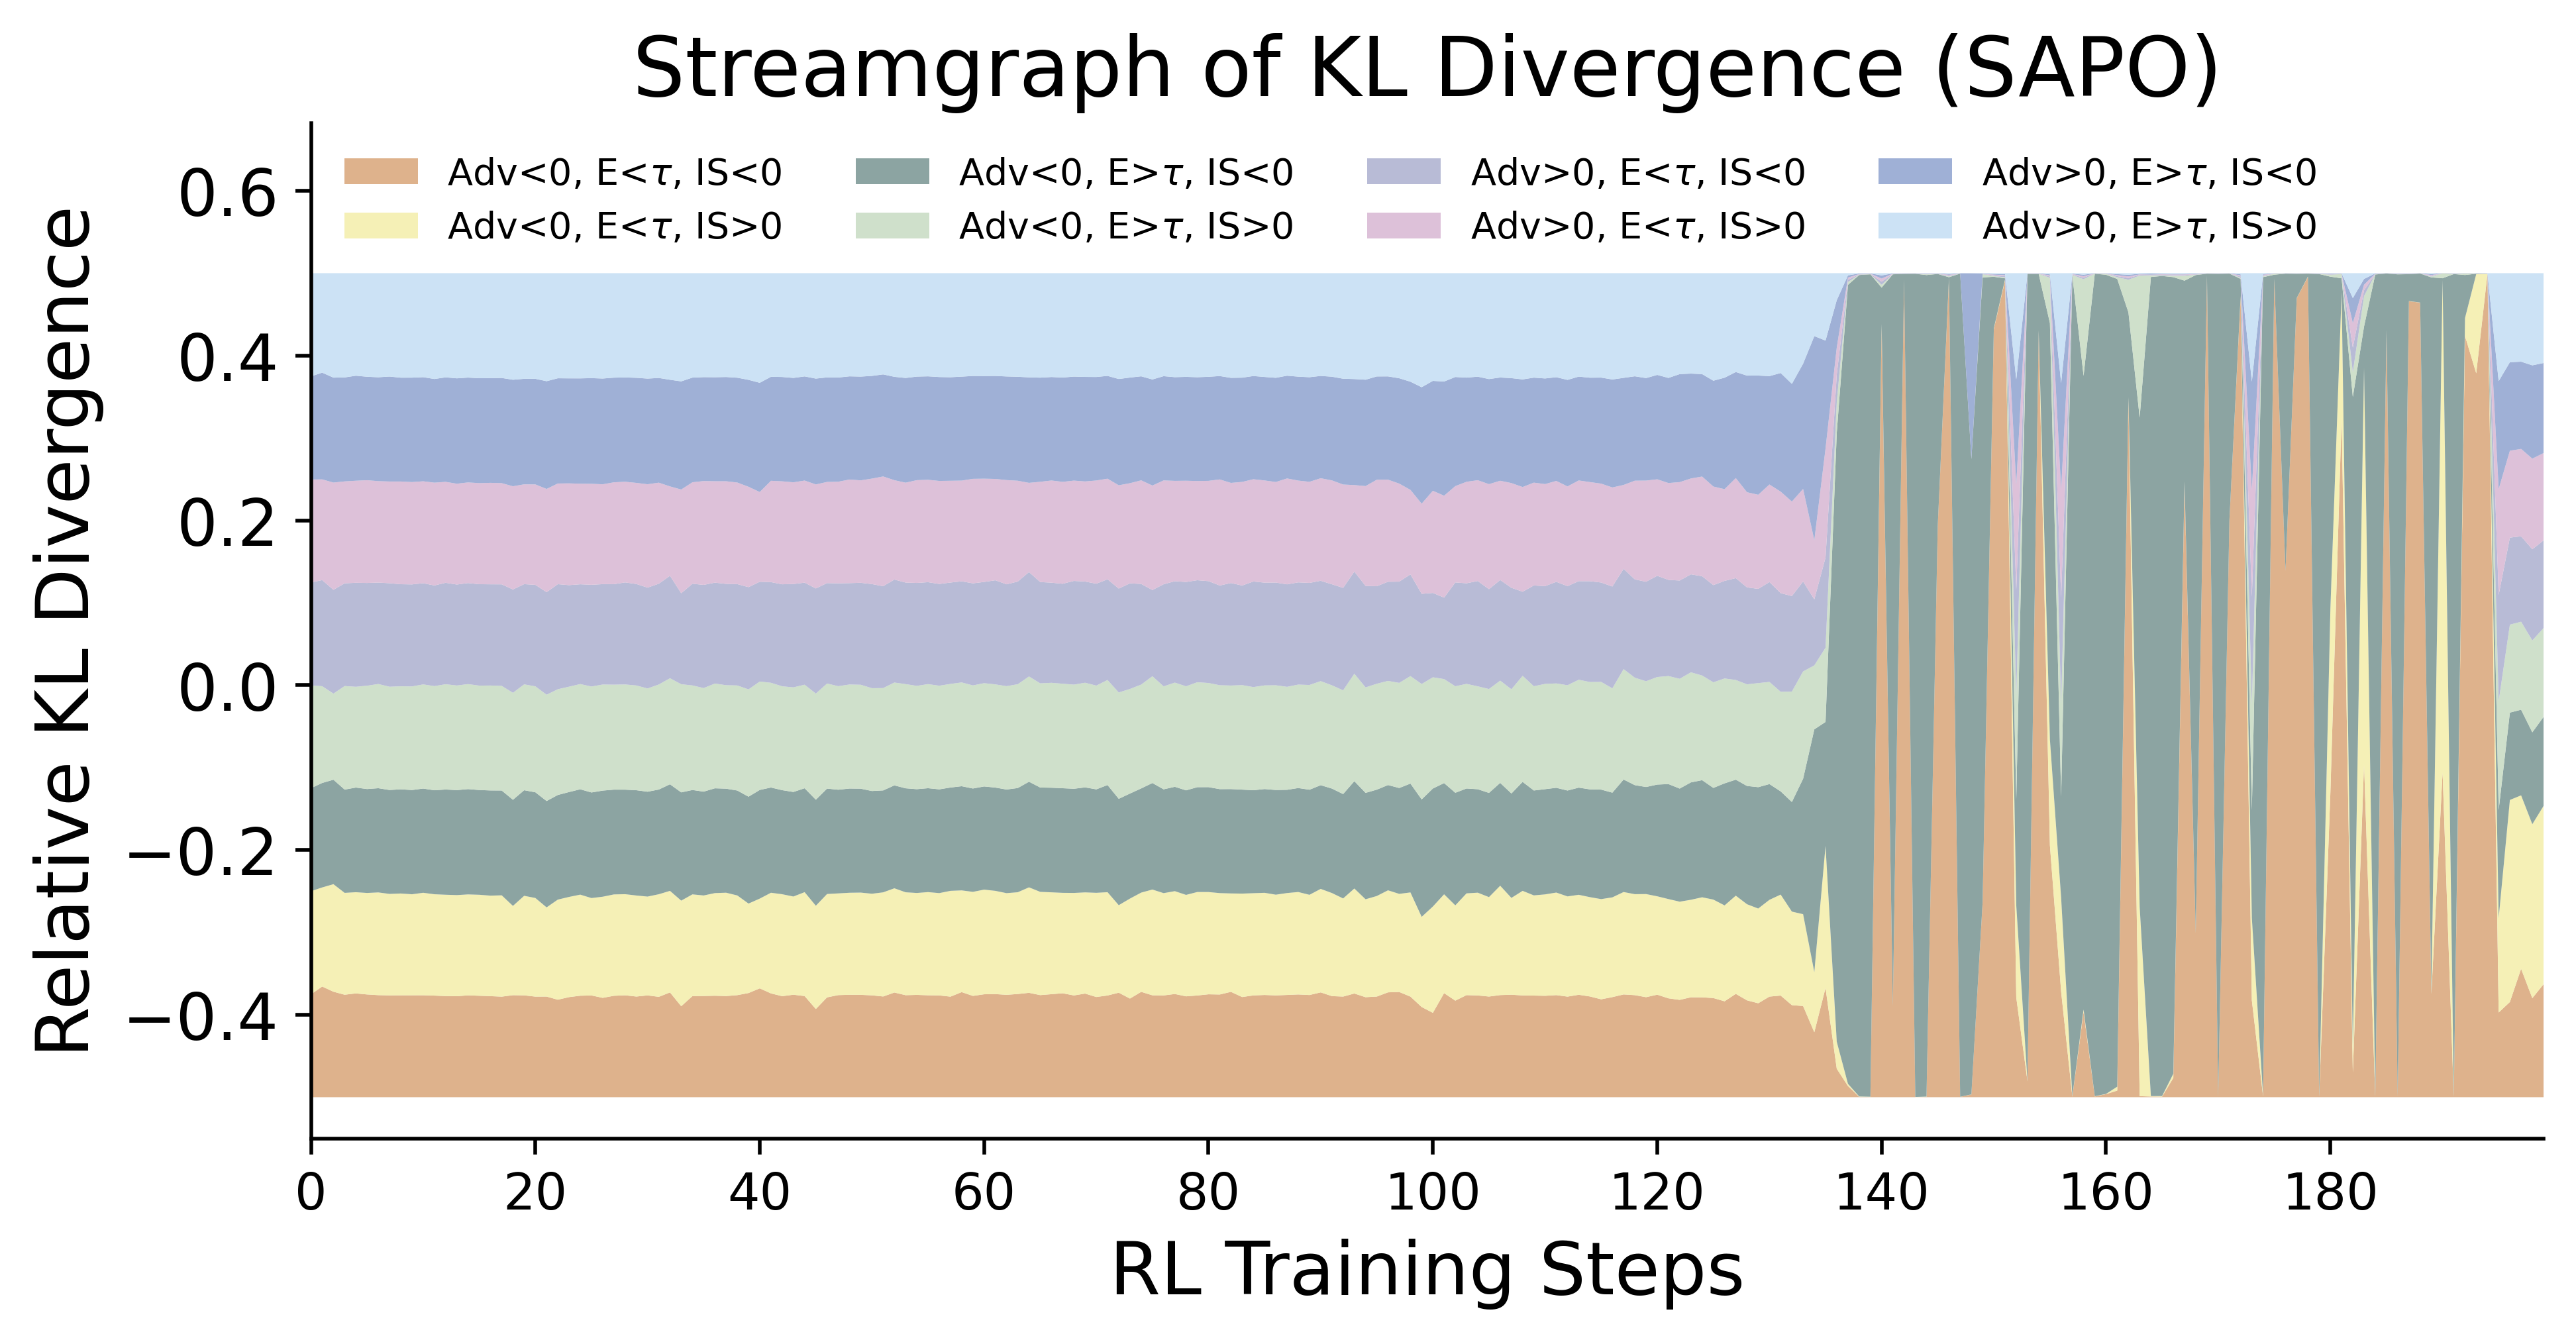

In [13]:
plot_streamgraph(
    group_kld_list,
    labels=[r"Adv<0, E<$\tau$, IS<0", r"Adv<0, E<$\tau$, IS>0", r"Adv<0, E>$\tau$, IS<0", r"Adv<0, E>$\tau$, IS>0", 
            r"Adv>0, E<$\tau$, IS<0", r"Adv>0, E<$\tau$, IS>0", r"Adv>0, E>$\tau$, IS<0", r"Adv>0, E>$\tau$, IS>0"],
    save_path="streamgraph.svg",
    title="Streamgraph of KL Divergence (SAPO)"
)

In [ ]:
import os
import numpy as np

base_dir = 'xxxx'
group_kld_list = [[] for _ in range(8)]  

files = [f for f in os.listdir(base_dir) if not f.startswith('.')]

for idx, file in enumerate(files):
    tensor_data, entropy_mean = get_group_mapping(file_name=f'{base_dir}/{file}', entropy_threshold=0.45)
    group_kld_mean = get_group_kld(tensor_data)  # {group_id: mean}
    print(group_kld_mean)
    # For each element in group_kld_mean, do a softmax!!!!
    values = np.array([group_kld_mean.get(k, 0) for k in range(8)], dtype=np.float64)
    exp_values = np.exp(values - np.max(values))  # for numerical stability
    softmaxed = exp_values / exp_values.sum() + 1e-8
    for k in range(8):
        group_kld_mean[k] = softmaxed[k]
    for group_id in range(8):
        value = group_kld_mean.get(group_id, 0)
        group_kld_list[group_id].append(value)

{2: np.float64(0.004150293863477647), 6: np.float64(0.003104201021991334), 0: np.float64(0.0032038293507496807), 3: np.float64(0.006090671610916372), 4: np.float64(0.002714011582780063), 7: np.float64(0.00819481832759327), 5: np.float64(0.006470545319812154), 1: np.float64(0.007150151633850628)}
{6: np.float64(0.03516275553623152), 0: np.float64(0.027375250978313545), 2: np.float64(0.0270519787715969), 4: np.float64(0.037290959571373565), 7: np.float64(0.03915436103889703), 5: np.float64(0.03983555720327918), 3: np.float64(0.02760838779525391), 1: np.float64(0.029908734091515808)}
{4: np.float64(0.041813151957174145), 2: np.float64(0.03032631562112955), 6: np.float64(0.04074590035558761), 0: np.float64(0.03800876058175377), 7: np.float64(0.03875545434495187), 5: np.float64(0.04238411825079647), 3: np.float64(0.030660305406175734), 1: np.float64(0.040703150713521104)}
{4: np.float64(0.053772943952997546), 6: np.float64(0.05218279505831163), 2: np.float64(0.04301566839491019), 0: np.floa

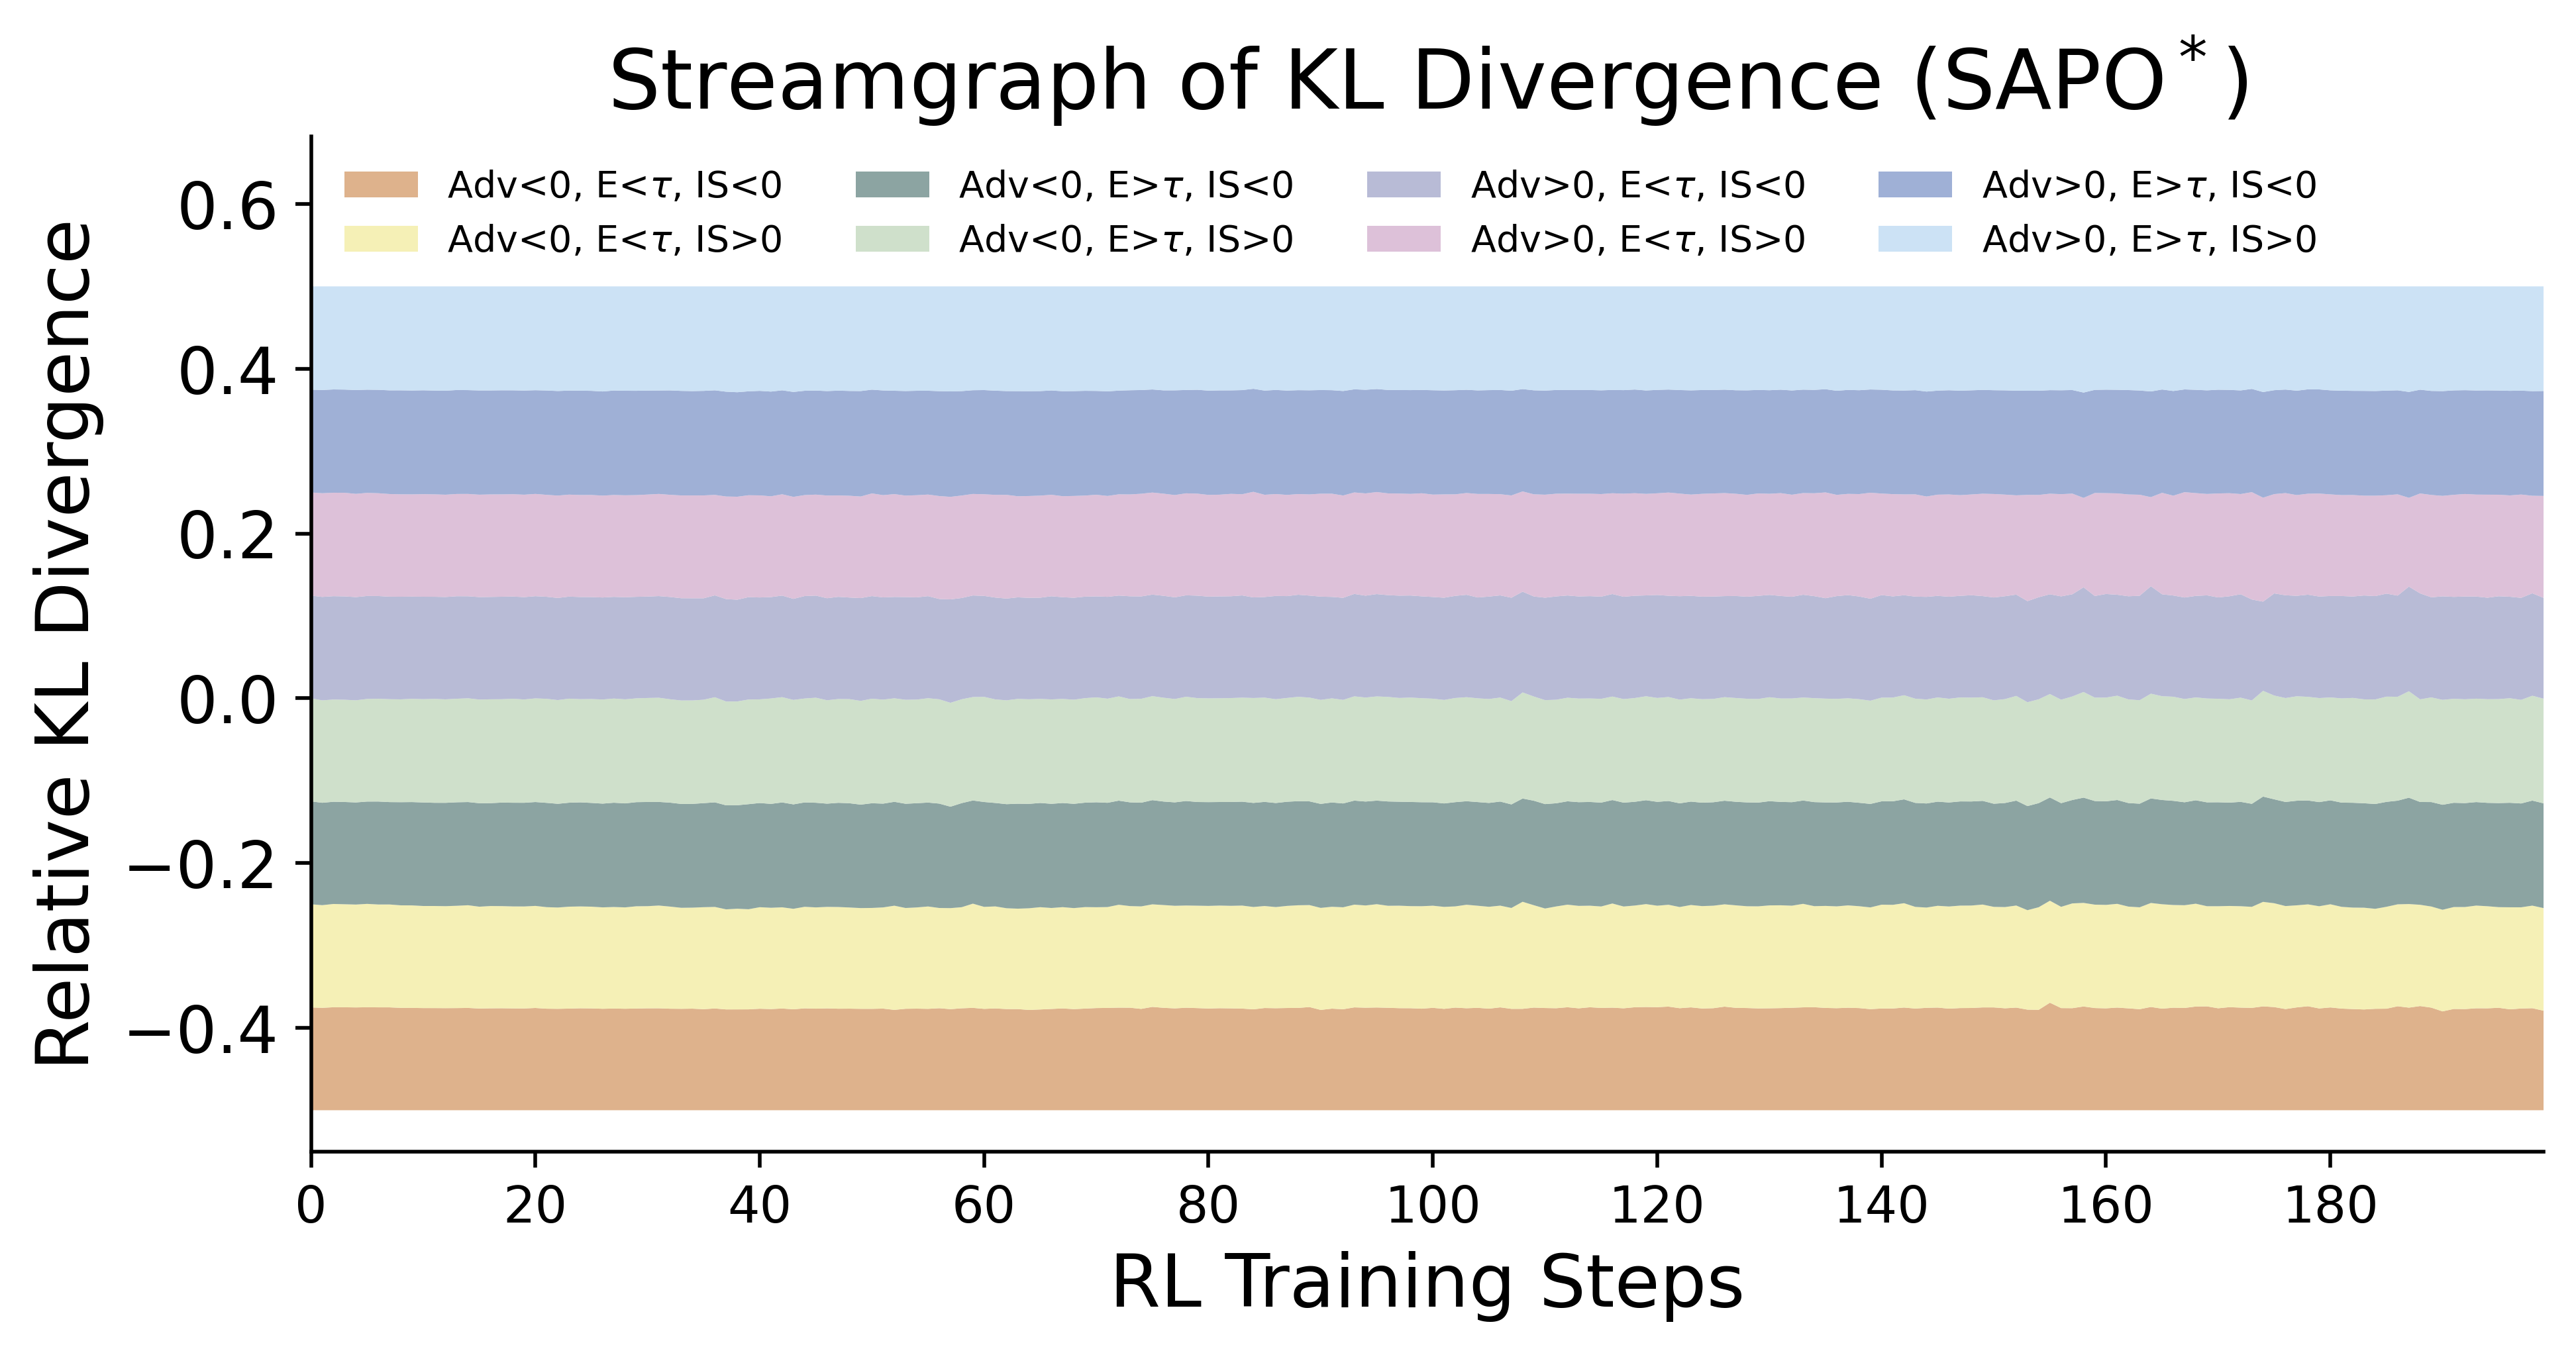

In [15]:
plot_streamgraph(
    group_kld_list,
    labels=[r"Adv<0, E<$\tau$, IS<0", r"Adv<0, E<$\tau$, IS>0", r"Adv<0, E>$\tau$, IS<0", r"Adv<0, E>$\tau$, IS>0", 
            r"Adv>0, E<$\tau$, IS<0", r"Adv>0, E<$\tau$, IS>0", r"Adv>0, E>$\tau$, IS<0", r"Adv>0, E>$\tau$, IS>0"],
    save_path="streamgraph.svg",
    title=r"Streamgraph of KL Divergence (SAPO$^*$)"
)

## Alfworld CISPO

In [ ]:
import os
import numpy as np

base_dir = 'xxxx'
group_kld_list = [[] for _ in range(8)]  

files = [f for f in os.listdir(base_dir) if not f.startswith('.')]

for idx, file in enumerate(files):
    tensor_data, entropy_mean = get_group_mapping(file_name=f'{base_dir}/{file}', entropy_threshold=0.45)
    group_kld_mean = get_group_kld(tensor_data)  # {group_id: mean}
    print(group_kld_mean)
    # For each element in group_kld_mean, do a softmax!!!!
    values = np.array([group_kld_mean.get(k, 0) for k in range(8)], dtype=np.float64)
    exp_values = np.exp(values - np.max(values))  # for numerical stability
    softmaxed = exp_values / exp_values.sum() + 1e-8
    for k in range(8):
        group_kld_mean[k] = softmaxed[k]
    for group_id in range(8):
        value = group_kld_mean.get(group_id, 0)
        group_kld_list[group_id].append(value)

{2: np.float64(0.0053879162485144984), 6: np.float64(0.004677330059262233), 3: np.float64(0.006454346398356928), 7: np.float64(0.00922449643736235), 5: np.float64(0.007244426524040586), 4: np.float64(0.004681967677752459), 1: np.float64(0.007382391143588671), 0: np.float64(0.004462679524950886)}
{4: np.float64(0.04738489292632094), 2: np.float64(0.03211975861116127), 0: np.float64(0.03806118767662178), 6: np.float64(0.04005193827257011), 3: np.float64(0.03398809052546725), 5: np.float64(0.05037653193255326), 7: np.float64(0.043551083891668486), 1: np.float64(0.04581071430568643)}
{6: np.float64(0.04413672763067658), 4: np.float64(0.04685708309066151), 2: np.float64(0.030262069420558875), 0: np.float64(0.04238714314742997), 5: np.float64(0.048584342296997346), 3: np.float64(0.028233208285658007), 7: np.float64(0.044610059603525626), 1: np.float64(0.04036921194504332)}
{4: np.float64(0.060427950440849316), 6: np.float64(0.06182540257640889), 2: np.float64(0.04559239680319447), 5: np.floa

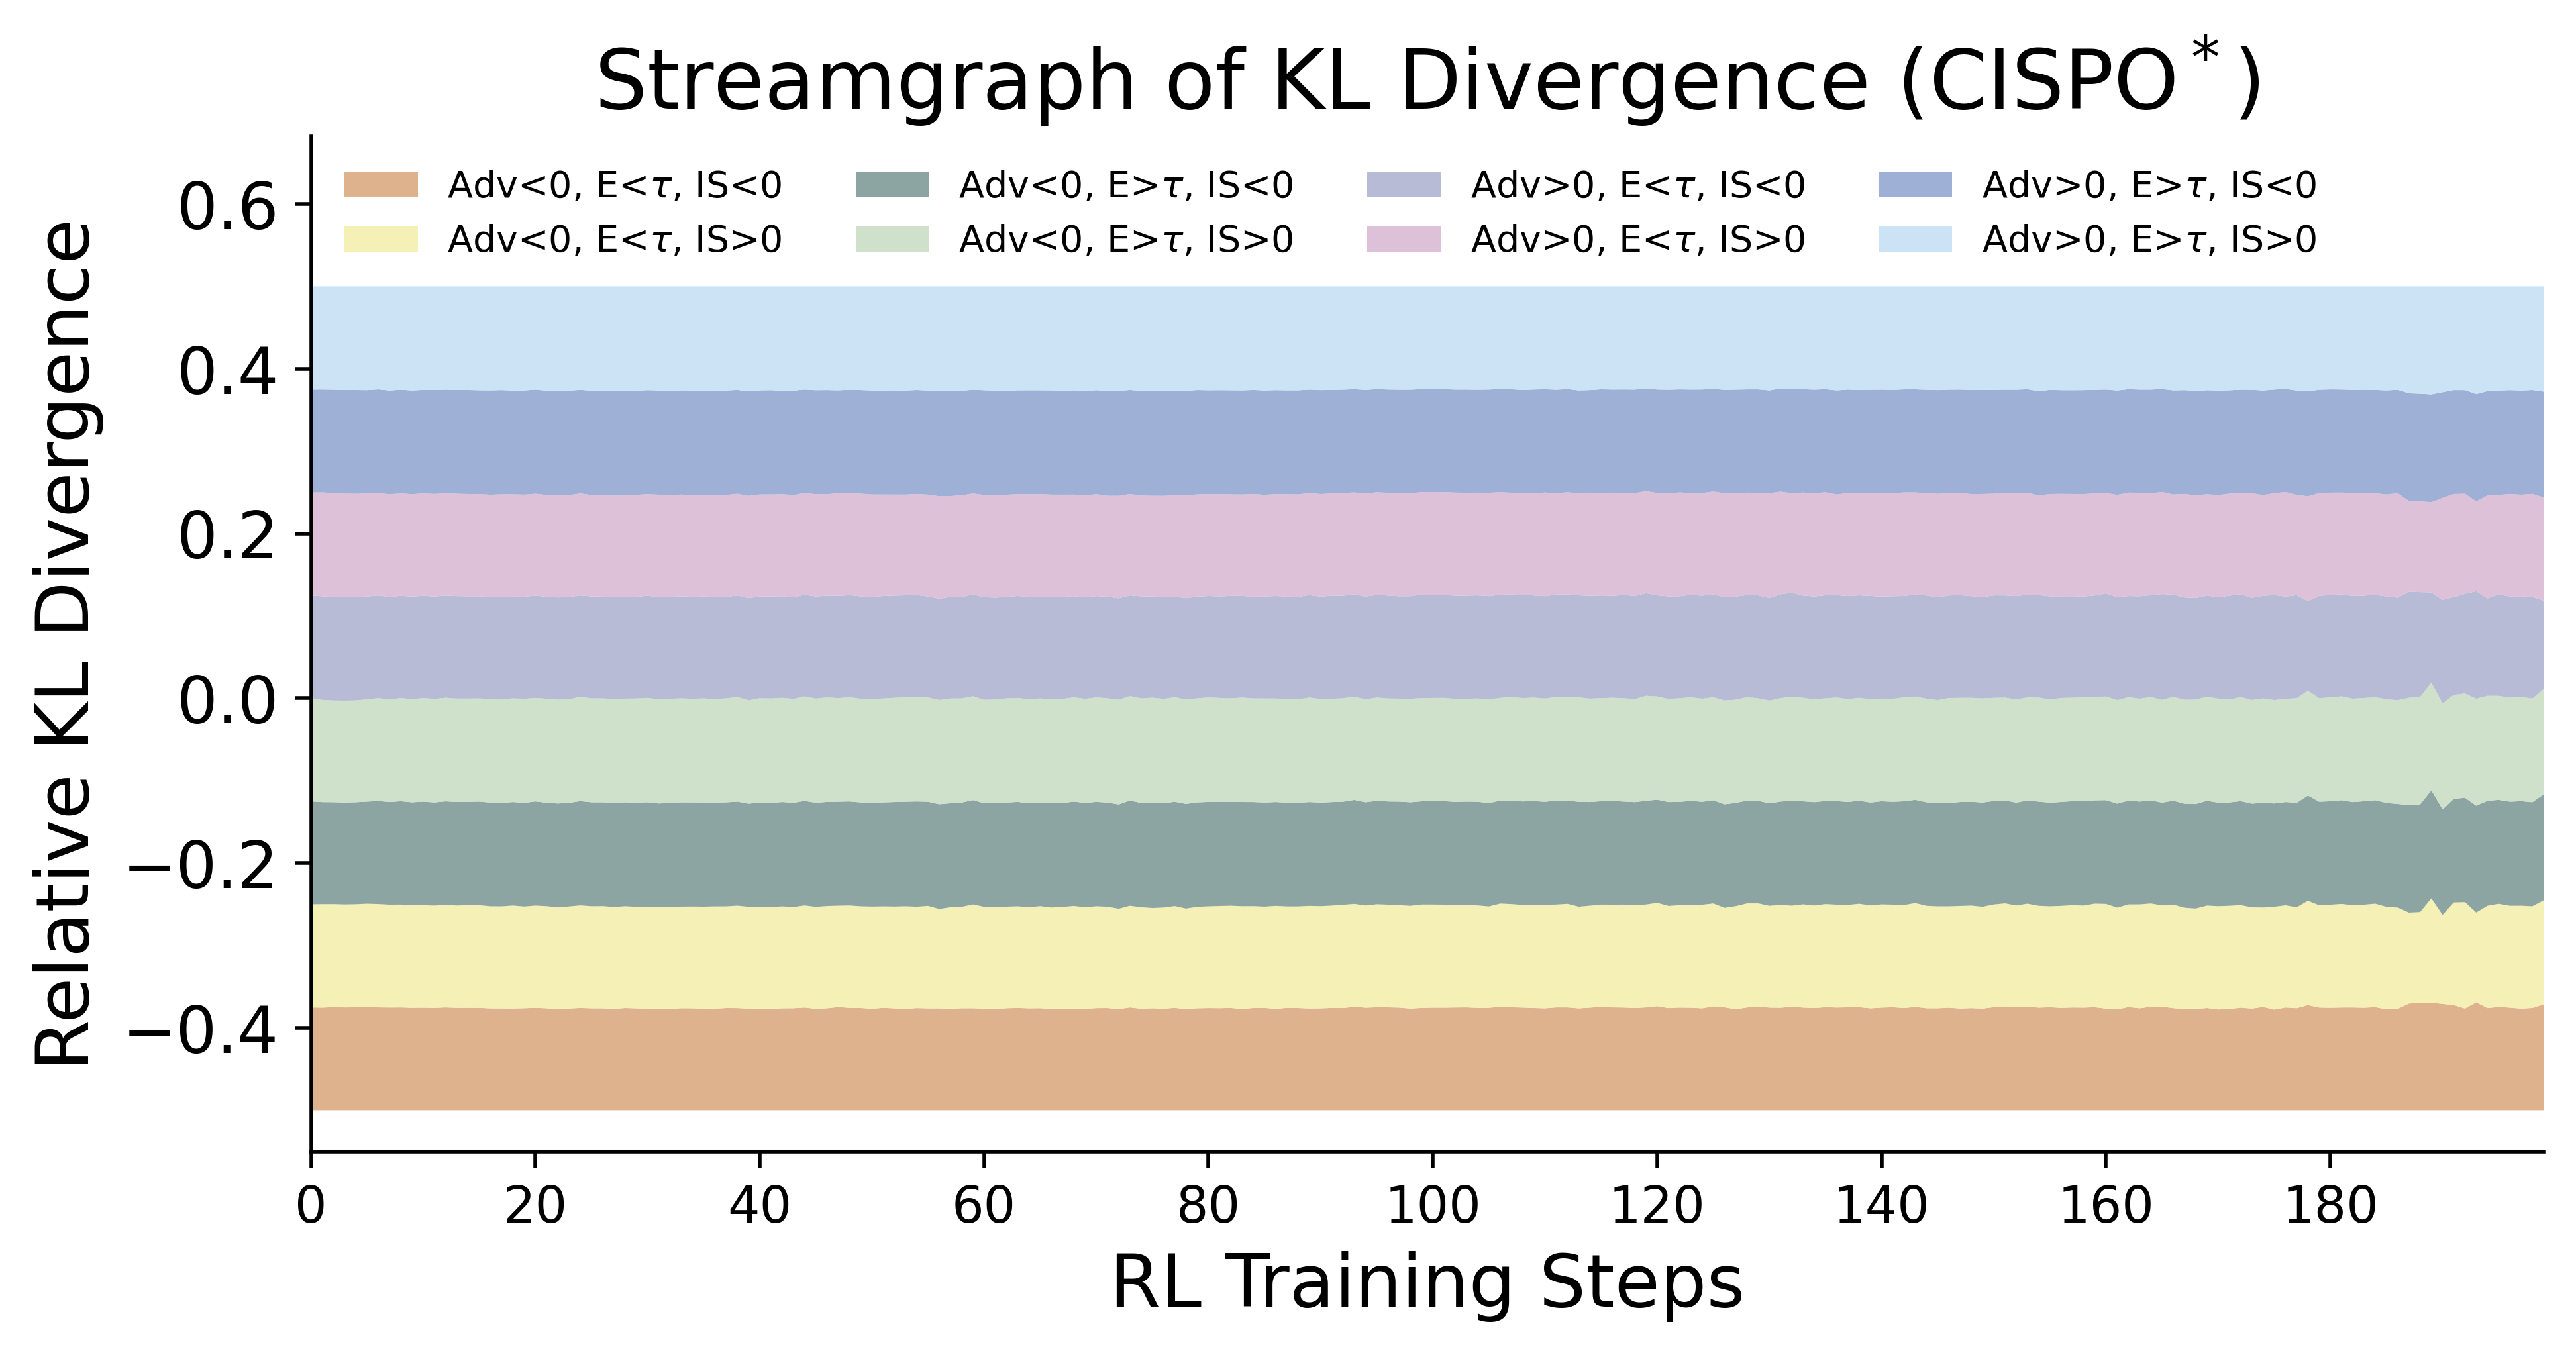

In [8]:
plot_streamgraph(
    group_kld_list,
    labels=[r"Adv<0, E<$\tau$, IS<0", r"Adv<0, E<$\tau$, IS>0", r"Adv<0, E>$\tau$, IS<0", r"Adv<0, E>$\tau$, IS>0", 
            r"Adv>0, E<$\tau$, IS<0", r"Adv>0, E<$\tau$, IS>0", r"Adv>0, E>$\tau$, IS<0", r"Adv>0, E>$\tau$, IS>0"],
    save_path="streamgraph.svg",
    title=r"Streamgraph of KL Divergence (CISPO$^*$)"
)

In [ ]:
import os
import numpy as np

base_dir = 'xxxxx'
group_kld_list = [[] for _ in range(8)]  

files = [f for f in os.listdir(base_dir) if not f.startswith('.')]

for idx, file in enumerate(files):
    tensor_data, entropy_mean = get_group_mapping(file_name=f'{base_dir}/{file}', entropy_threshold=0.45)
    group_kld_mean = get_group_kld(tensor_data)  # {group_id: mean}
    print(group_kld_mean)
    # For each element in group_kld_mean, do a softmax!!!!
    values = np.array([group_kld_mean.get(k, 0) for k in range(8)], dtype=np.float64)
    exp_values = np.exp(values - np.max(values))  # for numerical stability
    softmaxed = exp_values / exp_values.sum() + 1e-8
    for k in range(8):
        group_kld_mean[k] = softmaxed[k]
    for group_id in range(8):
        value = group_kld_mean.get(group_id, 0)
        group_kld_list[group_id].append(value)

{2: np.float64(0.008523387206090213), 6: np.float64(0.008649654971642206), 4: np.float64(0.006135556595967893), 3: np.float64(0.006128101683642977), 1: np.float64(0.00788536701238433), 5: np.float64(0.008121300340124687), 0: np.float64(0.007877765035193024), 7: np.float64(0.009718026172702432)}
{2: np.float64(0.11657442460062094), 6: np.float64(0.1257629134873764), 4: np.float64(0.12267568643815704), 0: np.float64(0.1574105995915275), 5: np.float64(0.08109334855891637), 7: np.float64(0.06630750914631112), 3: np.float64(0.05540855719517996), 1: np.float64(0.08661743139045328)}
{4: np.float64(0.15902778823085337), 6: np.float64(0.1636066563193476), 5: np.float64(0.1777139501702121), 7: np.float64(0.13056762761800936), 0: np.float64(0.16853329836260178), 1: np.float64(0.18585631226440533), 2: np.float64(0.14018433345893536), 3: np.float64(0.15365030246244238)}
{0: np.float64(0.14863003392439114), 2: np.float64(0.1270820359179881), 1: np.float64(0.14487291400288585), 4: np.float64(0.139957

/tmp/ipykernel_249005/3571725037.py:35: RuntimeWarning: Mean of empty slice.
  entropy_mean += entropy.mean()
/data1/whx/anaconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_249005/3571725037.py:38: RuntimeWarning: Mean of empty slice.
  ent_flag = 1 if entropy.mean() > entropy_threshold else 0
/tmp/ipykernel_249005/3571725037.py:39: RuntimeWarning: Mean of empty slice.
  is_flag = 1 if IS.mean() > 0 else 0
/tmp/ipykernel_249005/4238794754.py:12: RuntimeWarning: Mean of empty slice.
  kld = np.clip(kld, a_min=-10, a_max=10).mean()


{2: np.float64(1.1008979292500405), 0: np.float64(0.5922422781951662), 4: np.float64(0.29437971669791824), 6: np.float64(0.33066810342982633), 5: np.float64(0.31922484163986065), 7: np.float64(0.3310328521535762), 1: np.float64(0.265731017871452), 3: np.float64(0.3470606541512829)}
{6: np.float64(0.34627372221375313), 4: np.float64(0.30384208239906346), 2: np.float64(1.8557149803653108), 0: np.float64(4.219831184506965), 3: np.float64(0.448550852631004), 1: np.float64(0.44311064679452916), 5: np.float64(0.3110920552573681), 7: np.float64(0.3628639490239302)}
{4: np.float64(0.2952815671334491), 6: np.float64(0.3221427016651235), 0: np.float64(6.156951394948289), 2: np.float64(6.020813985539331), 3: np.float64(0.6851985372729312), 7: np.float64(0.31903418834556335), 5: np.float64(0.28931674999817764), 1: np.float64(0.6628476449173004)}
{4: np.float64(0.3007782369943666), 6: np.float64(0.3443369062091191), 2: np.float64(8.934427905752589), 0: np.float64(6.31411807878681), 1: np.float64(0.

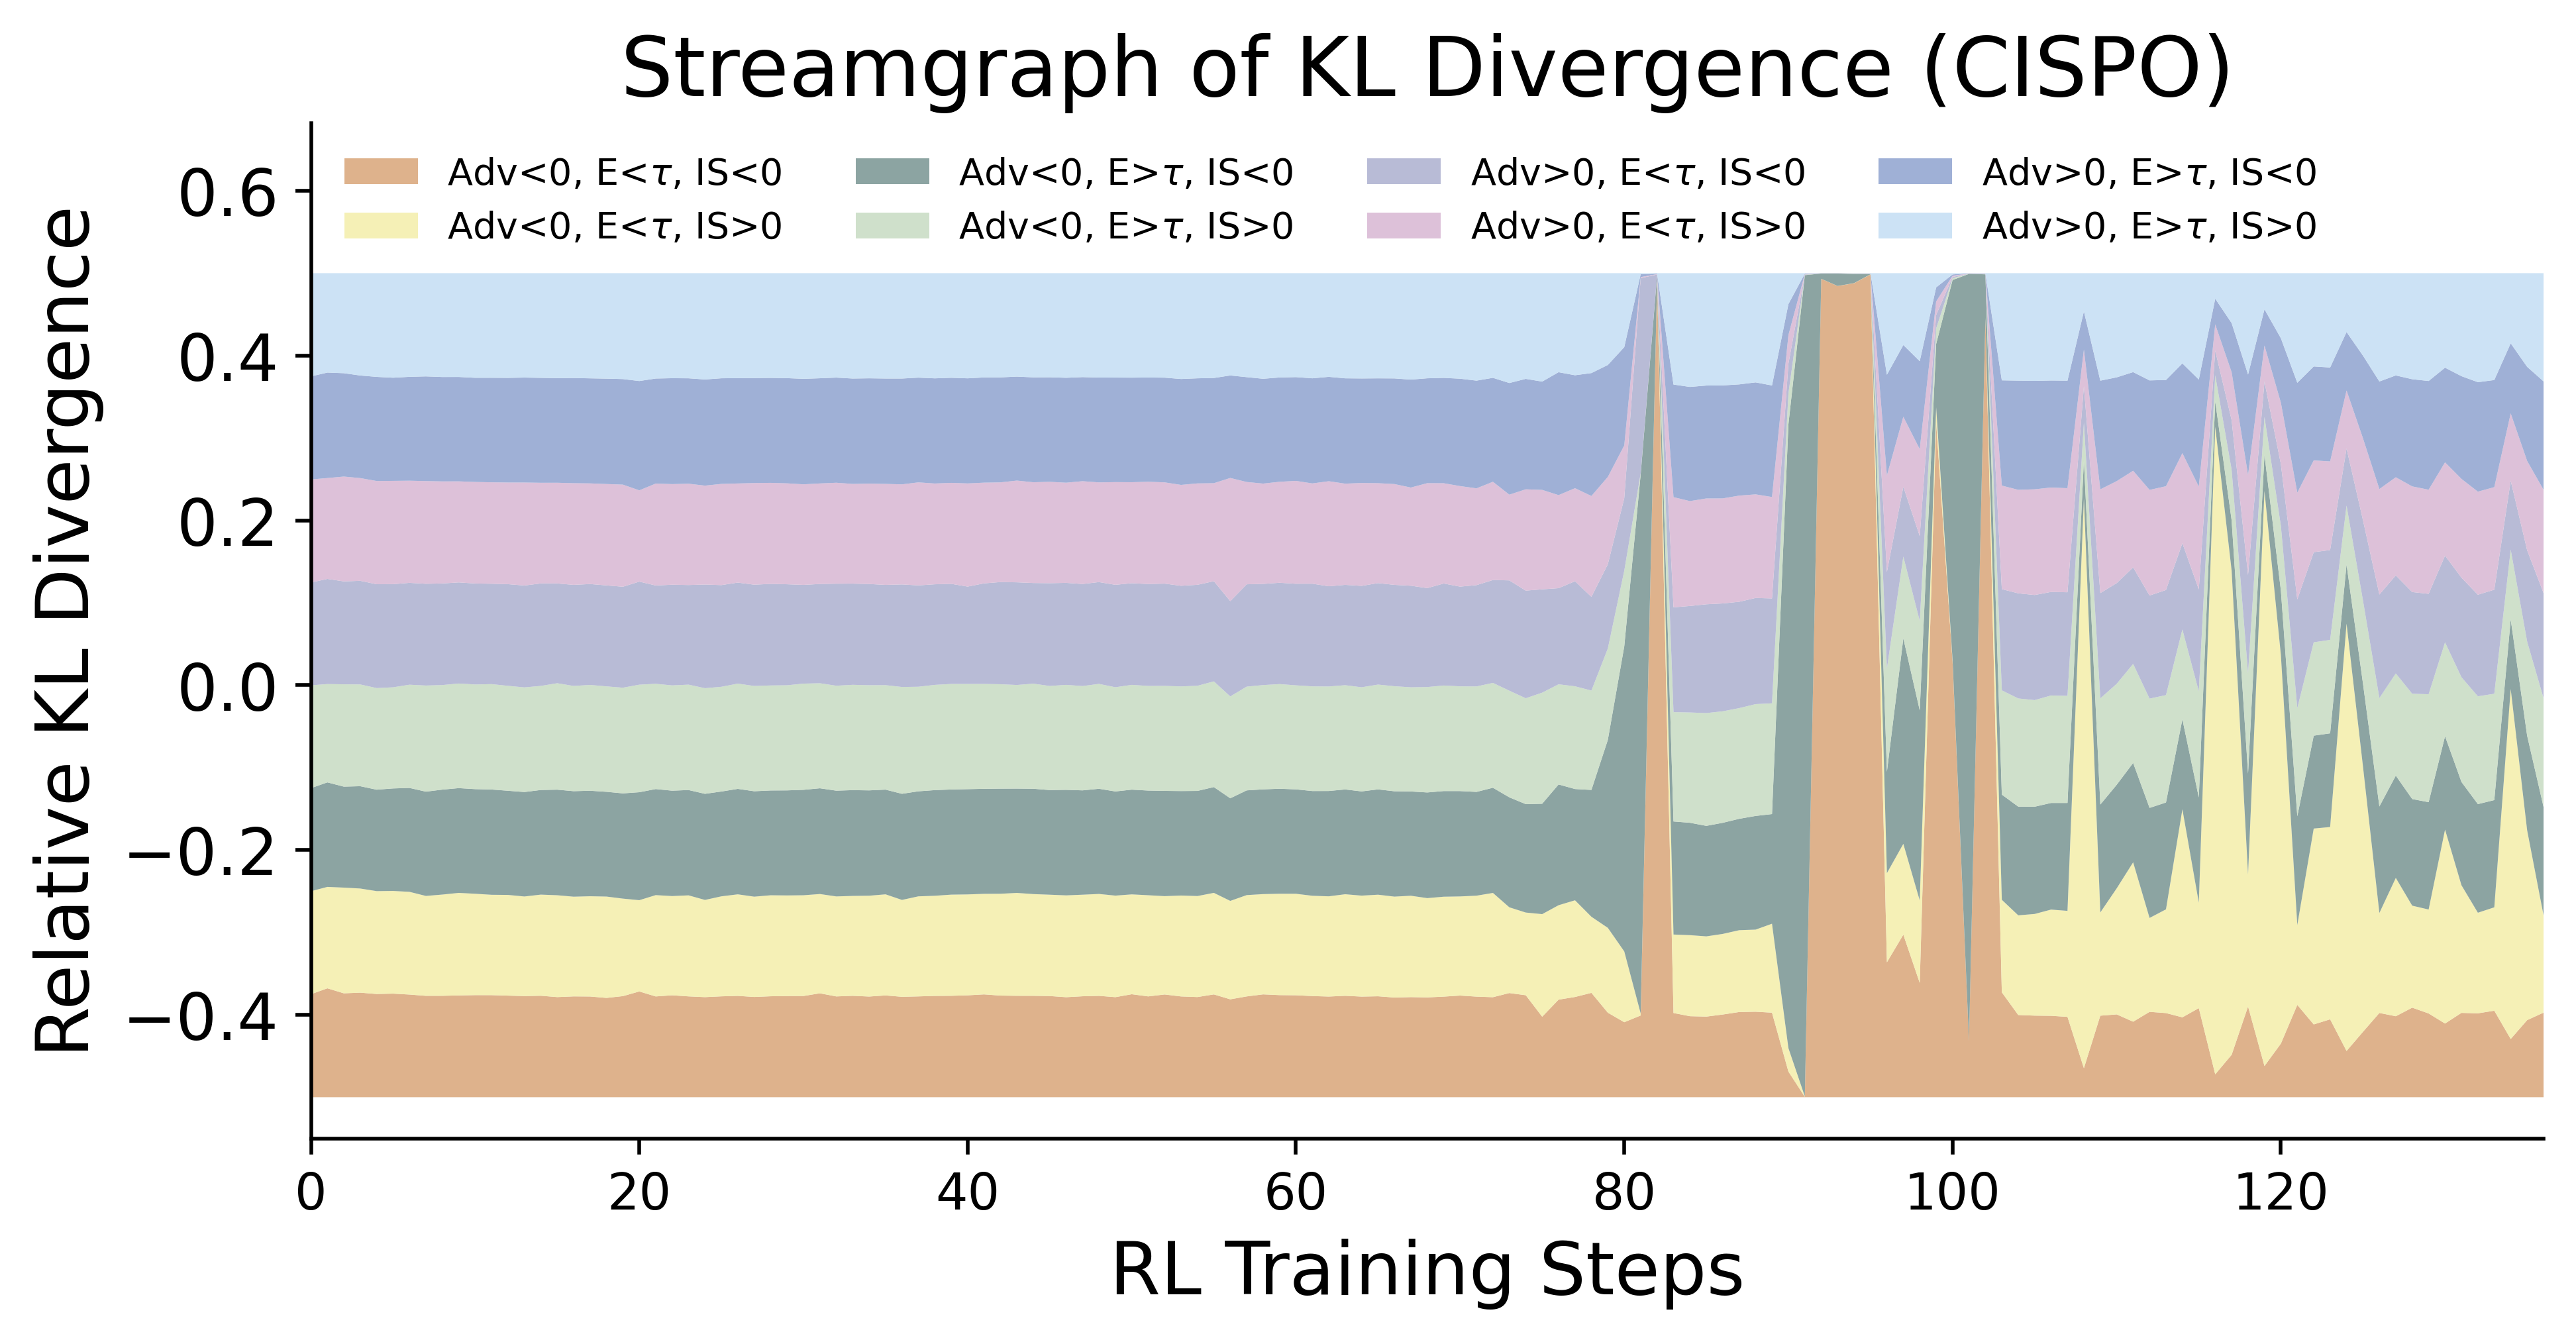

In [12]:
plot_streamgraph(
    group_kld_list,
    labels=[r"Adv<0, E<$\tau$, IS<0", r"Adv<0, E<$\tau$, IS>0", r"Adv<0, E>$\tau$, IS<0", r"Adv<0, E>$\tau$, IS>0", 
            r"Adv>0, E<$\tau$, IS<0", r"Adv>0, E<$\tau$, IS>0", r"Adv>0, E>$\tau$, IS<0", r"Adv>0, E>$\tau$, IS>0"],
    save_path="streamgraph_cispo.svg",
    title=r"Streamgraph of KL Divergence (CISPO)"
)